# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings
import warnings



In [ ]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

df = pd.read_parquet("2023-1.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/Colab Notebooks/NYC_Taxi_dataset')
print(os.listdir())

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        temp_df = pd.read_parquet(file_path)
        temp_df["tpep_pickup_datetime"] = pd.to_datetime(temp_df["tpep_pickup_datetime"])
        temp_df["pickup_date"] = temp_df["tpep_pickup_datetime"].dt.date
        temp_df["pickup_hour"] = temp_df["tpep_pickup_datetime"].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in temp_df["pickup_date"].unique():
            date_data = temp_df[temp_df["pickup_date"] == date]

            for hour in range(24):
                hour_data = date_data[date_data["pickup_hour"] == hour]

                if len(hour_data) == 0:
                    continue

                sample_size = max(1, int(len(hour_data) * 0.05))
                sample = hour_data.sample(n=sample_size, random_state=42)

                sampled_data = pd.concat([sampled_data, sample], ignore_index=True)

                # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

['2023-9.parquet', '2023-5.parquet', '2023-6.parquet', '2023-2.parquet', '2023-1.parquet', '2023-7.parquet', '2023-8.parquet', '2023-10.parquet', '2023-3.parquet', '2023-12.parquet', '2023-4.parquet', '2023-11.parquet', 'NYC_Taxi_2023_sampled.parquet']


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df.to_parquet('NYC_Taxi_2023_sampled.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file

df = pd.read_parquet('NYC_Taxi_2023_sampled.parquet')

In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,...,0.5,4.32,0.00,1.0,33.15,NaN,NaN,2023-09-01,0,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,0.5,0.00,0.00,1.0,10.10,2.5,0.00,2023-09-01,0,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,0.5,15.71,6.94,1.0,98.40,2.5,1.75,2023-09-01,0,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,0.5,0.00,0.00,1.0,64.70,2.5,0.00,2023-09-01,0,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,0.5,2.00,0.00,1.0,14.90,2.5,0.00,2023-09-01,0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987958 entries, 0 to 1987957
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed

df.reset_index(drop=True, inplace=True)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns

df.drop(columns=["airport_fee"], inplace=True)
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_date',
       'pickup_hour'],
      dtype='object')

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative

df[df["fare_amount"] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
df[df["fare_amount"] < 0]["RatecodeID"].value_counts()



,count
RatecodeID,


In [ ]:
# Find which columns have negative values

numeric_cols = df.select_dtypes(include=["number"]).columns

(df[numeric_cols] < 0).sum()

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
extra,3
mta_tax,76


In [ ]:
# fix these negative values
negative_cols = [
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "total_amount"
]

for col in negative_cols:
    df[col] = df[col].abs()

(df[negative_cols] < 0).sum()

,0
extra,0
mta_tax,0
improvement_surcharge,0
congestion_surcharge,0
Airport_fee,0
total_amount,0


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column

missing_prop = (df.isnull().sum() / len(df)) * 100
missing_prop.sort_values(ascending=False)

,0
Airport_fee,11.250791
store_and_fwd_flag,3.425475
congestion_surcharge,3.425475
RatecodeID,3.425475
passenger_count,3.425475
trip_distance,0.000000
tpep_dropoff_datetime,0.000000
tpep_pickup_datetime,0.000000
VendorID,0.000000
payment_type,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
df[df["passenger_count"].isnull()]

df["passenger_count"].fillna(df["passenger_count"].median(), inplace=True)
# Impute NaN values in 'passenger_count'
(df["passenger_count"] == 0).sum()

df.loc[df["passenger_count"] == 0, "passenger_count"] = df["passenger_count"].median()
(df["passenger_count"] == 0).sum()

/tmp/ipykernel_490/2716423671.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["passenger_count"].fillna(df["passenger_count"].median(), inplace=True)


np.int64(0)

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
df[df["RatecodeID"].isnull()]

df["RatecodeID"] = df["RatecodeID"].fillna(df["RatecodeID"].mode()[0])
df["RatecodeID"].isnull().sum()

np.int64(0)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge
df[df["congestion_surcharge"].isnull()]

df["congestion_surcharge"] = df["congestion_surcharge"].fillna(df["congestion_surcharge"].median())
df["congestion_surcharge"].isnull().sum()


np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna(df["store_and_fwd_flag"].mode()[0])
df.isnull().sum()

df[df["Airport_fee"].isnull()]
df["Airport_fee"] = df["Airport_fee"].fillna(df["Airport_fee"].median())
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour
count,1.987958e+06,1987958,1987958,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06,1.987958e+06
mean,1.733155e+00,2023-07-02 15:21:47.082752,2023-07-02 15:39:14.728863,1.372135e+00,3.850411e+00,1.610398e+00,1.652889e+02,1.640621e+02,1.163613e+00,1.991655e+01,1.588281e+00,4.953275e-01,3.547577e+00,5.969168e-01,9.990461e-01,2.898099e+01,2.314425e+00,1.295569e-01,1.427523e+01
min,1.000000e+00,2001-01-01 00:08:31,2001-01-01 14:13:51,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-02 16:04:03.500000,2023-04-02 16:24:32.750000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00,1.100000e+01
50%,2.000000e+00,2023-06-27 15:14:09,2023-06-27 15:33:26.500000,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00,1.500000e+01
75%,2.000000e+00,2023-10-06 19:47:00,2023-10-06 20:05:43,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00,1.900000e+01
max,6.000000e+00,2024-01-03 19:42:57,2024-01-03 20:15:55,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00,2.300000e+01
std,4.477026e-01,NaN,NaN,8.642118e-01,1.274057e+02,7.249979e+00,6.399614e+01,6.980467e+01,5.079520e-01,1.031501e+02,1.829516e+00,4.840168e-02,4.055571e+00,2.188709e+00,2.842713e-02,1.040497e+02,6.553612e-01,4.484234e-01,5.800682e+00


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
df = df[df["passenger_count"] <= 6]
df["passenger_count"].max()

6.0

In [ ]:
# Continue with outlier handling
df = df[df["trip_distance"] <= 250]

df = df[df["payment_type"] !=0]

df = df[~((df["trip_distance"] == 0) & (df["fare_amount"] == 0) & (df["PULocationID"] != df["DOLocationID"]))]

df = df[~((df["trip_distance"] < 0.01) & (df["fare_amount"] > 300))]


In [ ]:
# Do any columns need standardising?
# No standardization required for this dataset.
# Data has been cleaned and outliers have been handled.


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'pickup_date',
 'pickup_hour']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

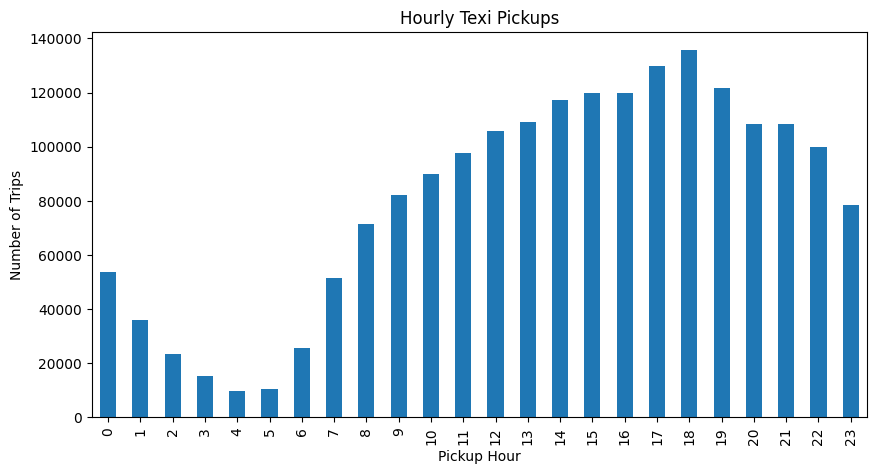

In [ ]:
# Find and show the hourly trends in taxi pickups
hourly_pickups = df.groupby("pickup_hour").size()

plt.figure(figsize=(10,5))
hourly_pickups.plot(kind="bar")
plt.title("Hourly Texi Pickups")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.show()

Text(0, 0.5, 'Number of Trips')

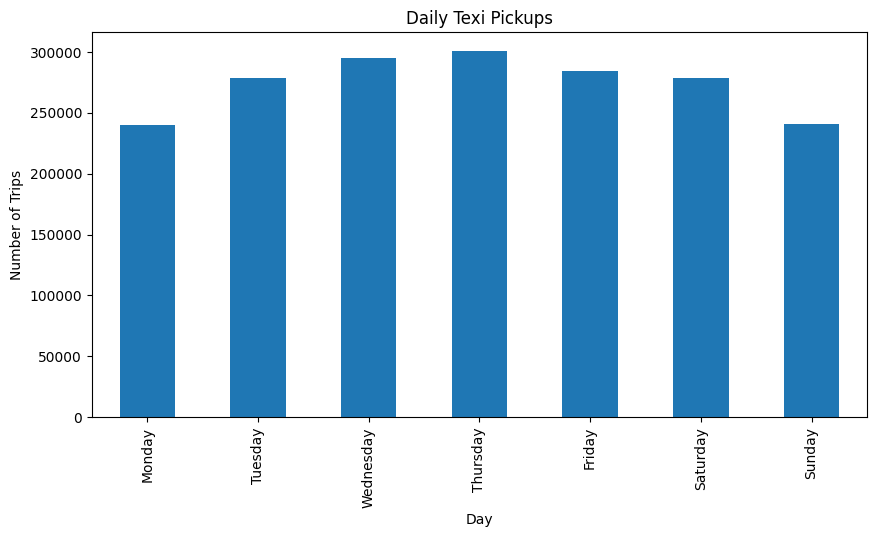

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_pickups = df.groupby("pickup_day").size().reindex(day_order)

plt.figure(figsize=(10,5))
daily_pickups.plot(kind="bar")
plt.title("Daily Texi Pickups")
plt.xlabel("Day")
plt.ylabel("Number of Trips")


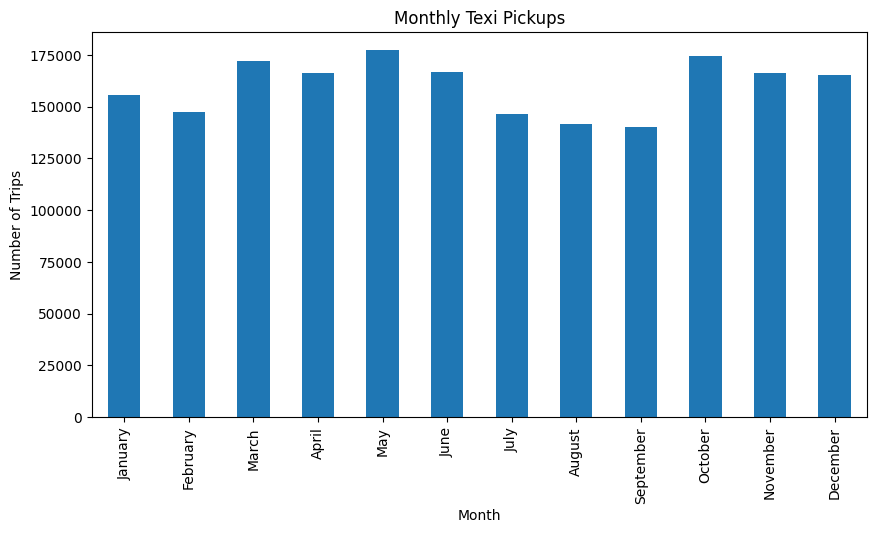

In [ ]:
# Show the monthly trends in pickups
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month_name()

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

monthly_pickups = df.groupby("pickup_month").size().reindex(month_order)

plt.figure(figsize=(10,5))
monthly_pickups.plot(kind="bar")
plt.title("Monthly Texi Pickups")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters
df.columns.tolist()


['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'pickup_date',
 'pickup_hour',
 'pickup_day',
 'pickup_month']

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.
df_financial = df[(df["fare_amount"] > 0) & (df["total_amount"] > 0) & (df["tip_amount"] >= 0) & (df["extra"] >= 0) & (df["mta_tax"] >= 0) & (df["tolls_amount"] >= 0) & (df["improvement_surcharge"] >= 0) & (df["congestion_surcharge"] >= 0) & (df["Airport_fee"] >= 0)].copy()
print("Original Shape  :", df.shape)
print("Filtered Shape  :", df_financial.shape)

Original Shape  : (1919727, 23)
Filtered Shape  : (1919125, 23)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

,pickup_month,total_amount
4,January,4250786.52
3,February,4019903.54
7,March,4840916.68
0,April,4760873.91
8,May,5183784.89
6,June,4877650.15
5,July,4244979.94
1,August,4137510.18
11,September,4364850.41
10,October,5201786.50


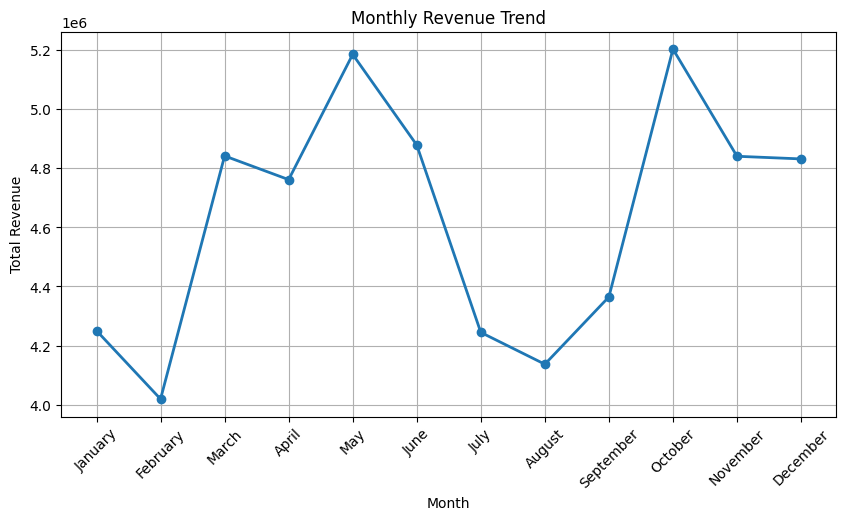

In [ ]:
# Group data by month and analyse monthly revenue

monthly_revenue = df_financial.groupby("pickup_month")["total_amount"].sum().reset_index()


month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# Convert month column to categorical and sort
monthly_revenue["pickup_month"] = pd.Categorical(
    monthly_revenue["pickup_month"],
    categories=month_order,
    ordered=True
)

monthly_revenue = monthly_revenue.sort_values("pickup_month")

# Display monthly revenue table
display(monthly_revenue)

# Plot monthly revenue trend
plt.figure(figsize=(10,5))
plt.plot(
    monthly_revenue["pickup_month"],
    monthly_revenue["total_amount"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

,total_amount
Quarter,
Q1,13111606.74
Q2,14822308.95
Q3,12747340.53
Q4,14872312.53


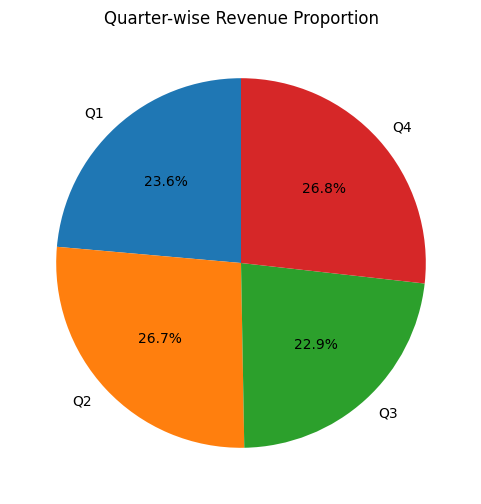

In [ ]:
# Calculate proportion of each quarter

quarter_map = {
    "January": "Q1",
    "February": "Q1",
    "March": "Q1",
    "April": "Q2",
    "May": "Q2",
    "June": "Q2",
    "July": "Q3",
    "August": "Q3",
    "September": "Q3",
    "October": "Q4",
    "November": "Q4",
    "December": "Q4"
}

df_financial["Quarter"] = df_financial["pickup_month"].map(quarter_map)

quarter_revenue = df_financial.groupby("Quarter")["total_amount"].sum()

display(quarter_revenue)

plt.figure(figsize=(6,6))
plt.pie(quarter_revenue, labels=quarter_revenue.index, autopct="%1.1f%%", startangle=90)

plt.title("Quarter-wise Revenue Proportion")
plt.show()



**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation between trip distance and fare amount: 0.16


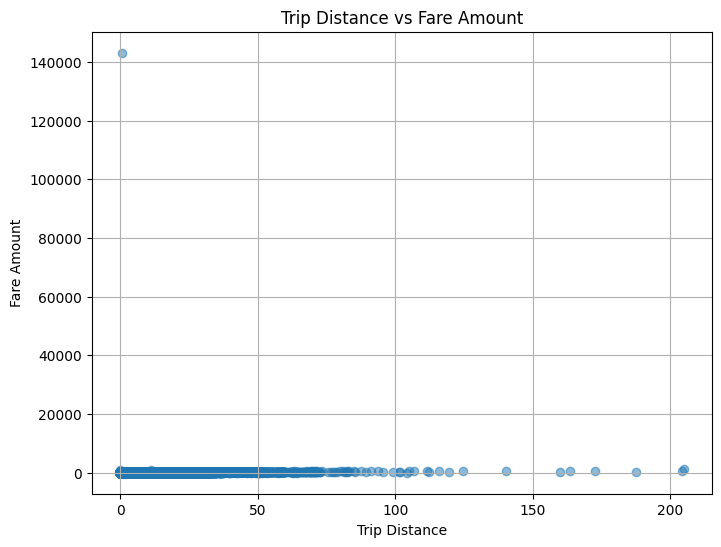

In [ ]:
# Show how trip fare is affected by distance
df_distance = df_financial[df_financial["trip_distance"] > 0]

corr = df_distance["trip_distance"].corr(df_distance["fare_amount"])
print("Correlation between trip distance and fare amount:", round(corr, 3))

plt.figure(figsize=(8, 6))
plt.scatter(df_distance["trip_distance"], df_distance["fare_amount"], alpha=0.5)
plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.grid(True)
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation: 0.045


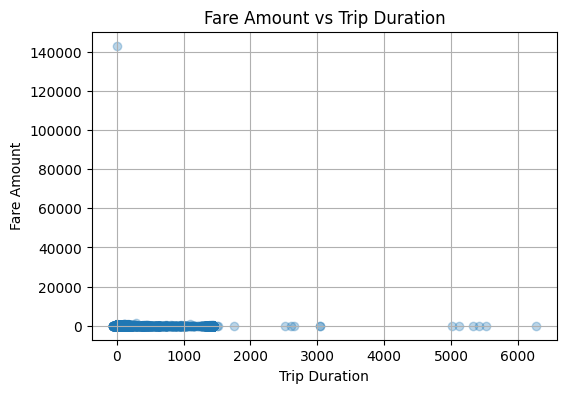

In [ ]:
# Show relationship between fare and trip duration
df["trip_duration"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["trip_duration"].head()

corr1 = df["fare_amount"].corr(df["trip_duration"])
print("Correlation:", round(corr1, 3))

plt.figure(figsize=(6,4))
plt.scatter(df["trip_duration"], df["fare_amount"], alpha=0.3)
plt.xlabel("Trip Duration")
plt.ylabel("Fare Amount")
plt.title("Fare Amount vs Trip Duration")
plt.grid(True)
plt.show()

Correlation: 0.007


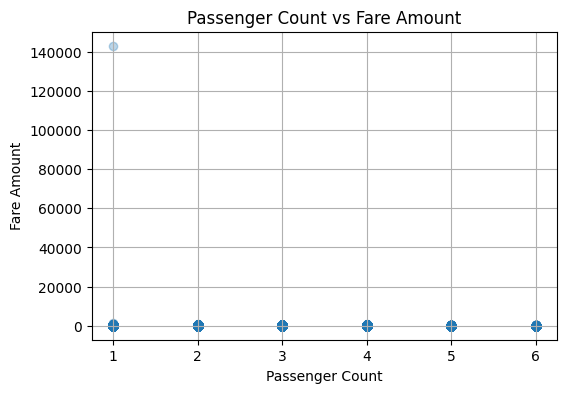

In [ ]:
# Show relationship between fare and number of passengers

corr2 = df["fare_amount"].corr(df["passenger_count"])
print("Correlation:",  round (corr2, 3))

plt.figure(figsize=(6, 4))
plt.scatter(df["passenger_count"], df["fare_amount"], alpha=0.3)
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.title("Passenger Count vs Fare Amount")
plt.grid(True)
plt.show()

Correlation: 0.572


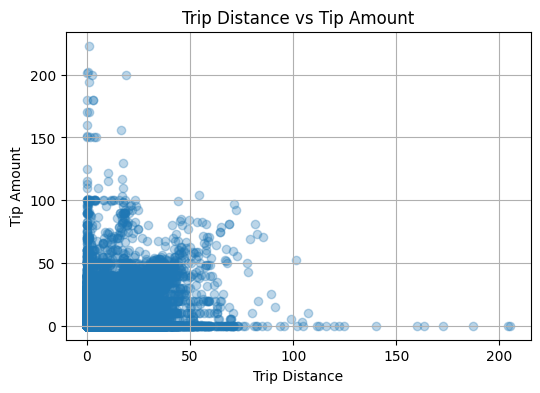

In [ ]:
# Show relationship between tip and trip distance

corr3 = df["tip_amount"].corr(df["trip_distance"])
print("Correlation:",  round (corr3, 3))

plt.figure(figsize=(6, 4))
plt.scatter(df["trip_distance"], df["tip_amount"], alpha=0.3)
plt.xlabel("Trip Distance")
plt.ylabel("Tip Amount")
plt.title("Trip Distance vs Tip Amount")
plt.grid(True)
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

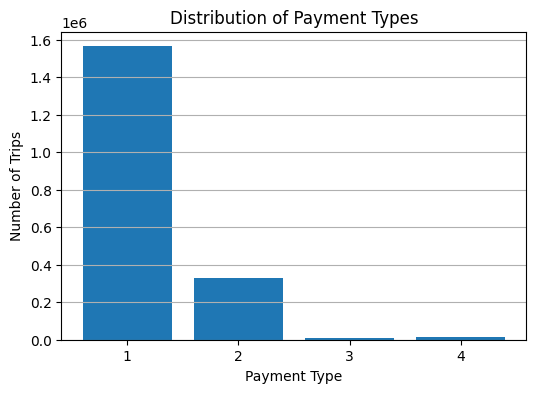

In [ ]:
# Analyse the distribution of different payment types (payment_type).

payment_counts = df["payment_type"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(payment_counts.index.astype(str), payment_counts.values)

plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.grid(axis="y")

plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
import os
print(os.listdir("/content"))

['.config', '2023-1.parquet', 'drive', 'sample_data']


In [ ]:
# import geopandas as gpd
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir("/content/drive/MyDrive"))
print(os.listdir("/content/drive/MyDrive/Colab Notebooks"))
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/UpGrad Assignment"))

import geopandas as gpd

# Read the shapefile using geopandas
# read the .shp file using gpd
zones = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/UpGrad Assignment/taxi_zones.shp")

zones.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Colab Notebooks', 'My Contact', 'Audio ', 'PDF ', 'Security and.txt', 'Report_NYC_Taxi_Operations_Starter.docx']
['EDA_NYC_Taxi_Analysis_Harish_Choubisa.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Untitled5.ipynb', 'Untitled6.ipynb', 'Untitled7.ipynb', 'Untitled9.ipynb', 'Untitled0.ipynb', 'Untitled10.ipynb', 'Untitled8.ipynb', 'Untitled11.ipynb', 'PythonPractice.py', 'PythonSets.py', 'Python.Dictionary.py', 'CodewithHarry.py', 'Dict. & Sets Apna college.py', 'Tuple.py', 'Vector.py', 'Matrix.py', 'Untitled12.ipynb', 'Untitled13.ipynb', 'Untitled14.ipynb', 'Untitled15.ipynb', 'Untitled16.ipynb', 'Untitled17.ipynb', 'File_Handling_Starter - Detailed.ipynb', 'File_Handling_Starter - Submission (1).ipynb', 'File_Handling_Starter - Submission.ipynb', 'Untitled18.ipynb', 'Untitled19.ipynb', 'Untitled1.ipynb', 'Untitled20.ipynb', 'Untitled21.

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [ ]:
# print(zones.info())
# zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID

trip_zone = df.merge(zones, left_on="PULocationID", right_on="LocationID", how="left")

df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,pickup_day,pickup_month,trip_duration
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,0.00,1.0,10.10,2.5,0.00,2023-09-01,0,Friday,September,2.483333
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,6.94,1.0,98.40,2.5,1.75,2023-09-01,0,Friday,September,44.583333
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,0.00,1.0,64.70,2.5,0.00,2023-09-01,0,Friday,September,38.116667
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,0.00,1.0,14.90,2.5,0.00,2023-09-01,0,Friday,September,6.300000
5,2,2023-09-01 00:41:08,2023-09-01 00:54:33,5.0,4.39,1.0,N,79,263,1,...,0.00,1.0,28.92,2.5,0.00,2023-09-01,0,Friday,September,13.416667


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips

trip_count = trip_zone.groupby("PULocationID").size().reset_index(name="trip_count")

trip_count.head()

,PULocationID,trip_count
0,1,226
1,2,2
2,3,44
3,4,1962
4,5,14


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame
zones = zones.merge(trip_count, left_on="LocationID", right_on="PULocationID", how="left")

zones["trip_count"] = zones["trip_count"].fillna(0)

zones.head()



,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,226.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,44.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,1962.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,14.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

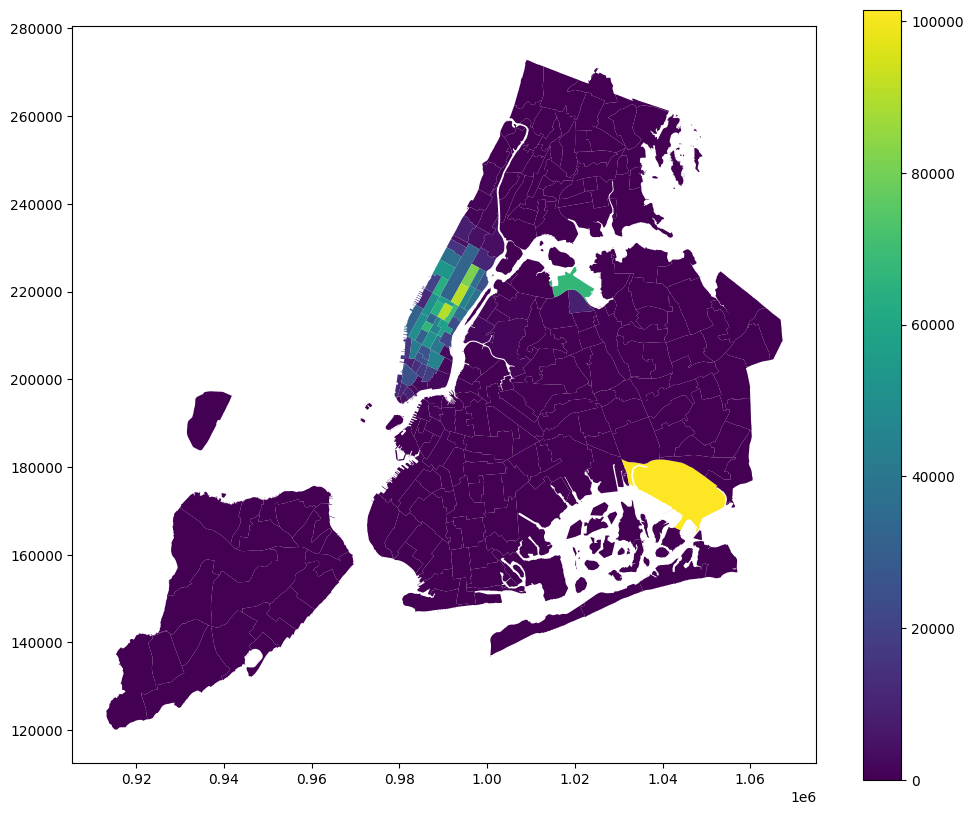

In [ ]:
# Define figure and axis

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it

zones.plot(column="trip_count", ax=ax, legend=True)

plt.show()


In [ ]:
# can you try displaying the zones DF sorted by the number of trips?

zones.sort_values(by="trip_count", ascending=False).head(10)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",132.0,101526.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,91162.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,90057.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,81368.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,68875.0
137,138,0.107467,0.000537,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031...",138.0,67341.0
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",186.0,66407.0
229,230,0.031028,0.000056,Times Sq/Theatre District,230,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21...",230.0,64244.0
141,142,0.038176,0.000076,Lincoln Square East,142,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21...",142.0,63831.0
169,170,0.045769,0.000074,Murray Hill,170,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21...",170.0,57141.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day

df['hour'] = df['tpep_pickup_datetime'].dt.hour

df['trip_duration_hours'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 3600

speed_df = df[(df['trip_distance'] > 0) & (df['trip_duration_hours'] > 0)]

route_speed = (speed_df.groupby(['PULocationID', 'DOLocationID', 'hour'])
               .agg(avg_distance=('trip_distance', 'mean'),
                    avg_duration=('trip_duration_hours', 'mean'))
               .reset_index())

route_speed['avg_speed'] = (route_speed['avg_distance'] / route_speed['avg_duration'])

route_speed.sort_values(by='avg_speed').head(10)

,PULocationID,DOLocationID,hour,avg_distance,avg_duration,avg_speed
102160,232,65,13,0.490000,92.040556,0.005324
114783,243,264,17,0.180000,23.159167,0.007772
61178,142,142,5,0.560000,23.559167,0.023770
120277,258,258,1,0.020000,0.762500,0.026230
33345,100,7,8,0.220000,5.573889,0.039470
6437,40,65,21,1.120000,23.907222,0.046848
39434,113,235,22,0.280000,5.820556,0.048105
89117,194,194,16,0.010000,0.204444,0.048913
95138,226,145,18,1.563333,30.179352,0.051801
9687,45,45,10,0.050000,0.840556,0.059484


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

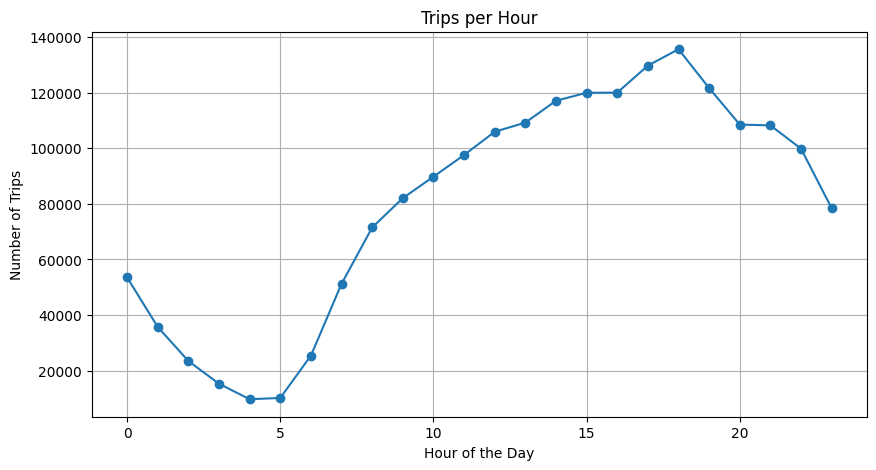

Busiest hour: 18
Number of Trips: 135622


In [ ]:
# Visualise the number of trips per hour and find the busiest hour

hourly_trips = (df.groupby("hour")
                .size()
                .reset_index(name="trip_count"))

plt.figure(figsize=(10, 5))
plt.plot(hourly_trips["hour"], hourly_trips["trip_count"], marker="o")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Trips")
plt.title("Trips per Hour")
plt.grid(True)
plt.show()

busiest_hour = hourly_trips.loc[hourly_trips["trip_count"].idxmax(),]

print("Busiest hour:", busiest_hour["hour"])
print("Number of Trips:", busiest_hour["trip_count"])

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.01

# Find top 5 busiest hours
top5_hours = hourly_trips.sort_values(by="trip_count", ascending=False).head(5)

# Scale to actual trips
top5_hours["actual_trips_count"] = (top5_hours["trip_count"] / sample_fraction).astype(int)

print(top5_hours)



    hour  trip_count  actual_trips_count
18    18      135622            13562200
17    17      129730            12973000
19    19      121639            12163900
16    16      120001            12000100
15    15      119972            11997200


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

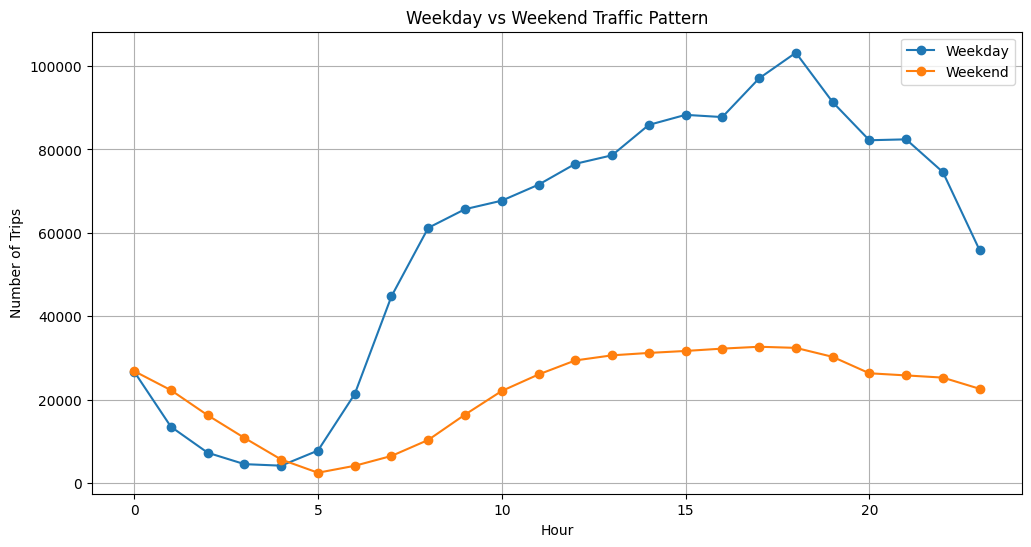

In [ ]:
# Compare traffic trends for weekdays and weekends

# Create day type
df["day_type"] = df["pickup_day"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

# Count trips
traffic = (
    df.groupby(["hour", "day_type"])
      .size()
      .reset_index(name="trip_count")
)

# Plot
plt.figure(figsize=(12,6))

for day in ["Weekday", "Weekend"]:
    temp = traffic[traffic["day_type"] == day]
    plt.plot(temp["hour"], temp["trip_count"], marker="o", label=day)

plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.title("Weekday vs Weekend Traffic Pattern")
plt.legend()
plt.grid(True)
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones

top_pickups = (
    df.groupby("PULocationID")
      .size()
      .reset_index(name="pickup_count")
      .sort_values("pickup_count", ascending=False)
      .head(10)
)

top_dropoffs = (
    df.groupby("DOLocationID")
      .size()
      .reset_index(name="dropoff_count")
      .sort_values("dropoff_count", ascending=False)
      .head(10)

)

print("Top 10 Pickup Zones")
print(top_pickups)

print("\Top 10 Dropoff Zones")
print(top_dropoffs)

pickup_hourly = (
    df.groupby(["hour", "PULocationID"])
      .size()
      .reset_index(name="pickup_count")
)

dropoff_hourly = (
    df.groupby(["hour", "DOLocationID"])
      .size()
      .reset_index(name="dropoff_count")
)

print("\nHourly Pickup Trend")
print(pickup_hourly.head())

print("\nHourly Dropoff Trend")
print(dropoff_hourly.head())

<>:23: SyntaxWarning: invalid escape sequence '\T'
<>:23: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_490/2801528684.py:23: SyntaxWarning: invalid escape sequence '\T'
  print("\Top 10 Dropoff Zones")


Top 10 Pickup Zones
     PULocationID  pickup_count
125           132        101526
229           237         91162
154           161         90057
228           236         81368
155           162         68875
131           138         67341
178           186         66407
222           230         64244
135           142         63831
163           170         57141
\Top 10 Dropoff Zones
     DOLocationID  dropoff_count
230           236          85285
231           237          81230
156           161          75171
224           230          59233
165           170          56777
157           162          54727
137           142          54015
233           239          53663
136           141          50766
67             68          48543

Hourly Pickup Trend
   hour  PULocationID  pickup_count
0     0             4           234
1     0             6             2
2     0             7            30
3     0            10             5
4     0            11             2

Hourl

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pickup_counts = df.groupby("PULocationID").size().reset_index(name="pickup_count")
dropoff_counts = df.groupby("DOLocationID").size().reset_index(name="dropoff_count")

ratio_df = pickup_counts.merge(dropoff_counts, left_on="PULocationID", right_on="DOLocationID", how="outer").fillna(0)

ratio_df["pickup_dropoff_ratio"] = ratio_df["pickup_count"] / (ratio_df["dropoff_count"] + 1)

top10 = ratio_df.sort_values(by="pickup_dropoff_ratio", ascending=False).head(10)

bottom10 = ratio_df.sort_values(by="pickup_dropoff_ratio", ascending=True).head(10)

print("Top 10 Pickup/Dropoff Ratios")
print(top10)

print("\nBottom 10 Pickup/Dropoff Ratios")
print(bottom10)


Top 10 Pickup/Dropoff Ratios
     PULocationID  pickup_count  DOLocationID  dropoff_count  \
69           70.0        8752.0          70.0         1062.0   
127         132.0      101526.0         132.0        21999.0   
133         138.0       67341.0         138.0        23298.0   
194         199.0           2.0           0.0            0.0   
181         186.0       66407.0         186.0        42083.0   
109         114.0       25302.0         114.0        18357.0   
42           43.0       32279.0          43.0        23475.0   
244         249.0       42381.0         249.0        31948.0   
157         162.0       68875.0         162.0        54727.0   
156         161.0       90057.0         161.0        75171.0   

     pickup_dropoff_ratio  
69               8.233302  
127              4.614818  
133              2.890296  
194              2.000000  
181              1.577963  
109              1.378255  
42               1.374979  
244              1.326520  
157           

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_df = df[(df["hour"] >= 23) | (df["hour"] <= 5)]

night_pickups = (
    night_df.groupby("PULocationID")
            .size()
            .reset_index(name="pickup_count")
            .sort_values("pickup_count", ascending=False)
            .head(10)
)

night_dropoffs = (
    night_df.groupby("DOLocationID")
            .size()
            .reset_index(name="dropoff_count")
            .sort_values("dropoff_count", ascending=False)
            .head(10)
)

print("Top 10 Night Pickup Zones")
print(night_pickups)

print("\nTop 10 Night Dropoff Zones")
print(night_dropoffs)

Top 10 Night Pickup Zones
     PULocationID  pickup_count
71             79         16266
114           132         15176
222           249         13046
42             48         10892
130           148         10063
99            114          9150
204           230          8566
163           186          7226
144           164          6407
60             68          6286

Top 10 Night Dropoff Zones
     DOLocationID  dropoff_count
77             79           8714
46             48           7148
164           170           6533
66             68           6096
102           107           6024
135           141           5505
255           263           5180
241           249           5166
222           230           4862
142           148           4602


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)
night_df = df[(df["hour"] >= 23) | (df["hour"] <= 5)]

# Daytime hours
day_df = df[(df["hour"] > 5) & (df["hour"] < 23)]

# Calculate revenue
night_revenue = night_df["total_amount"].sum()
day_revenue = day_df["total_amount"].sum()

total_revenue = night_revenue + day_revenue

print("Night Revenue :", night_revenue)
print("Day Revenue   :", day_revenue)

print("\nNight Revenue Share : {:.2f}%".format((night_revenue / total_revenue) * 100))
print("Day Revenue Share   : {:.2f}%".format((day_revenue / total_revenue) * 100))

Night Revenue : 6662868.94
Day Revenue   : 48892652.08999999

Night Revenue Share : 11.99%
Day Revenue Share   : 88.01%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts
fare_df = df[(df["trip_distance"] > 0) & (df["passenger_count"] > 0)].copy()

fare_df["fare_per_mile_per_passenger"] = fare_df["fare_amount"] / fare_df["trip_distance"]

fare_df



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,Airport_fee,pickup_date,pickup_hour,pickup_day,pickup_month,trip_duration,hour,trip_duration_hours,day_type,fare_per_mile_per_passenger
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,0.00,2023-09-01,0,Friday,September,2.483333,0,0.041389,Weekday,9.107143
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,1.75,2023-09-01,0,Friday,September,44.583333,0,0.743056,Weekday,3.791983
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,0.00,2023-09-01,0,Friday,September,38.116667,0,0.635278,Weekday,4.354486
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,0.00,2023-09-01,0,Friday,September,6.300000,0,0.105000,Weekday,11.126761
5,2,2023-09-01 00:41:08,2023-09-01 00:54:33,5.0,4.39,1.0,N,79,263,1,...,0.00,2023-09-01,0,Friday,September,13.416667,0,0.223611,Weekday,4.350797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1987953,1,2023-11-28 23:08:31,2023-11-28 23:18:32,1.0,1.40,1.0,N,170,137,2,...,0.00,2023-11-28,23,Tuesday,November,10.016667,23,0.166944,Weekday,7.642857
1987954,1,2023-11-28 23:31:06,2023-11-28 23:41:07,1.0,1.20,1.0,N,246,230,1,...,0.00,2023-11-28,23,Tuesday,November,10.016667,23,0.166944,Weekday,8.916667
1987955,2,2023-11-28 23:12:57,2023-11-28 23:29:24,1.0,2.56,1.0,N,263,230,2,...,0.00,2023-11-28,23,Tuesday,November,16.450000,23,0.274167,Weekday,6.367188
1987956,1,2023-11-28 23:01:53,2023-11-28 23:16:08,1.0,2.50,1.0,N,230,262,1,...,0.00,2023-11-28,23,Tuesday,November,14.250000,23,0.237500,Weekday,5.960000


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

Average Fare Per Mile by Hour
    hour  fare_per_mile
0      0      10.539081
1      1      11.300103
2      2       9.827740
3      3      11.623063
4      4      12.909493
5      5      15.371975
6      6      11.333730
7      7      10.145538
8      8      10.745561
9      9      10.360023
10    10      12.965632
11    11      10.952875
12    12      12.022079
13    13      11.822679
14    14      11.770719
15    15      12.521730
16    16      13.816259
17    17      12.059450
18    18      11.685936
19    19      11.662179
20    20       9.567377
21    21       9.465692
22    22      10.243769
23    23      10.830010

Average Fare Per Mile by Day
  pickup_day  fare_per_mile
0     Friday      10.902779
1     Monday      11.089494
2   Saturday      10.910316
3     Sunday      12.607031
4   Thursday      11.284357
5    Tuesday      12.110541
6  Wednesday      11.177248


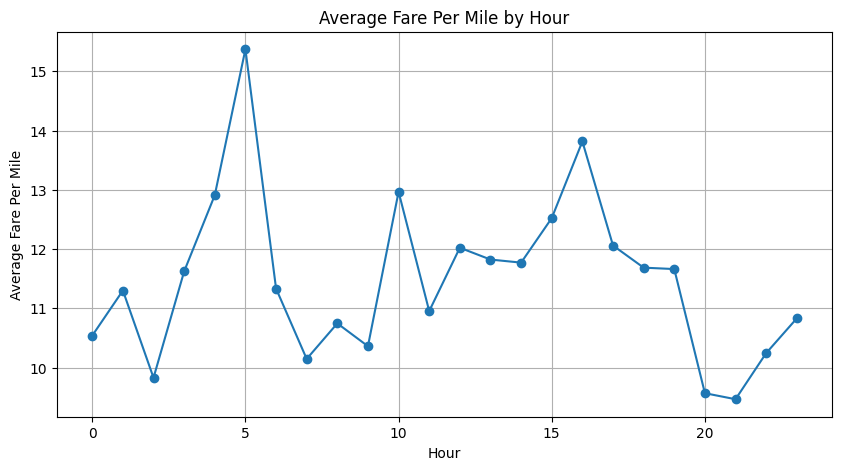

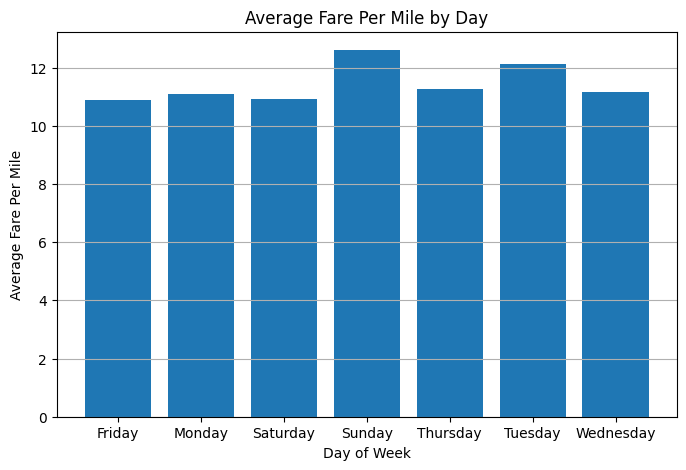

In [ ]:
# Compare the average fare per mile for different days and for different times of the day

fare_df = df[df["trip_distance"] > 0].copy()

fare_df["fare_per_mile"] = fare_df["fare_amount"] / fare_df["trip_distance"]

# Average fare per mile by hour
hourly_fare = (
    fare_df.groupby("hour")["fare_per_mile"]
    .mean()
    .reset_index()
)

# Average fare per mile by day
daily_fare = (
    fare_df.groupby("pickup_day")["fare_per_mile"]
    .mean()
    .reset_index()
)

print("Average Fare Per Mile by Hour")
print(hourly_fare)

print("\nAverage Fare Per Mile by Day")
print(daily_fare)

# Plot Hourly Fare
plt.figure(figsize=(10,5))
plt.plot(hourly_fare["hour"], hourly_fare["fare_per_mile"], marker="o")
plt.xlabel("Hour")
plt.ylabel("Average Fare Per Mile")
plt.title("Average Fare Per Mile by Hour")
plt.grid(True)
plt.show()

# Plot Daily Fare
plt.figure(figsize=(8,5))
plt.bar(daily_fare["pickup_day"].astype(str), daily_fare["fare_per_mile"])
plt.xlabel("Day of Week")
plt.ylabel("Average Fare Per Mile")
plt.title("Average Fare Per Mile by Day")
plt.grid(axis="y")
plt.show()



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

   hour  VendorID  fare_per_mile
0     0         1       6.786146
1     0         2      11.639952
2     1         1       7.054049
3     1         2      12.547426
4     2         1       7.006928


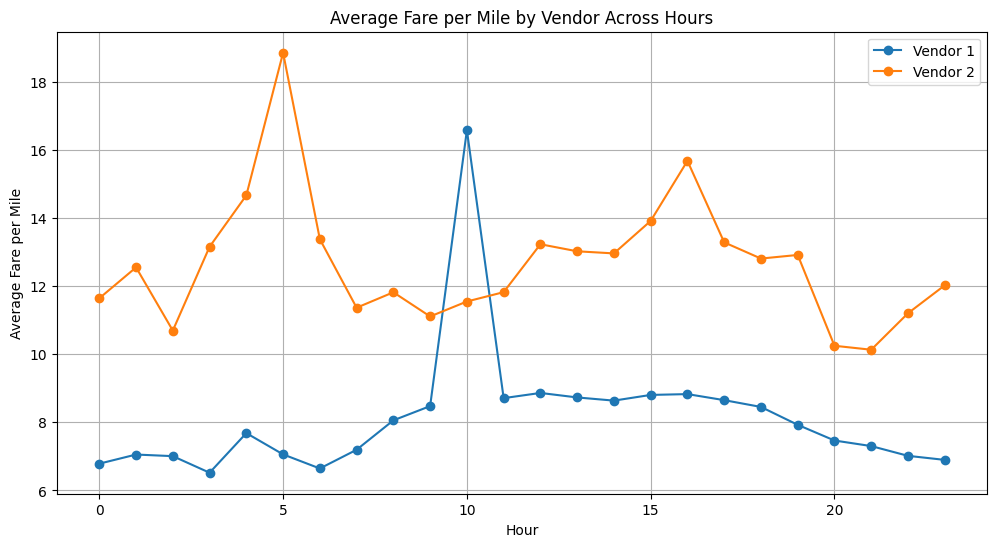

In [ ]:
# Compare fare per mile for different vendors

vendor_df = df[df["trip_distance"] > 0].copy()

vendor_df["fare_per_mile"] = (
    vendor_df["fare_amount"] / vendor_df["trip_distance"]
)

vendor_hourly = (
    vendor_df.groupby(["hour", "VendorID"])["fare_per_mile"]
    .mean()
    .reset_index()
)

print(vendor_hourly.head())

plt.figure(figsize=(12,6))

for vendor in vendor_hourly["VendorID"].unique():
    data = vendor_hourly[vendor_hourly["VendorID"] == vendor]
    plt.plot(data["hour"], data["fare_per_mile"],
             marker="o", label=f"Vendor {vendor}")

plt.xlabel("Hour")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Vendor Across Hours")
plt.legend()
plt.grid(True)
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


/tmp/ipykernel_490/1558675527.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_result = (tier_df.groupby(["VendorID", "distance_tier"])


   VendorID distance_tier  fare_per_mile
0         1     0-2 miles      10.635983
1         1     2-5 miles       6.380441
2         1      5> miles       4.423407
3         2     0-2 miles      17.997131
4         2     2-5 miles       6.549678
5         2      5> miles       4.502226


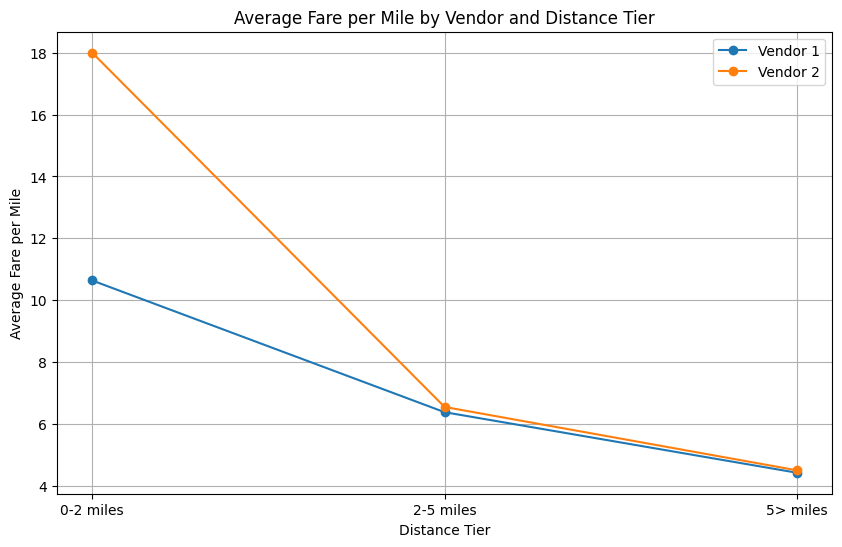

In [ ]:
# Defining distance tiers
tier_df = df[df["trip_distance"] > 0].copy()

tier_df["fare_per_mile"] = tier_df["fare_amount"] / tier_df["trip_distance"]

tier_df["distance_tier"] = pd.cut(
    tier_df["trip_distance"],
    bins=[0, 2, 5, float("inf")],
    labels=["0-2 miles", "2-5 miles", "5> miles"],
)

tier_result = (tier_df.groupby(["VendorID", "distance_tier"])
             ["fare_per_mile"]
             .mean()
             .reset_index())

print(tier_result)

plt.figure(figsize=(10,6))

for vendor in tier_result["VendorID"].unique():
    data = tier_result[tier_result["VendorID"] == vendor]
    plt.plot(data["distance_tier"], data["fare_per_mile"], marker="o", label=f"Vendor {vendor}")

plt.xlabel("Distance Tier")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Vendor and Distance Tier")
plt.legend()
plt.grid(True)
plt.show()


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

Average Tip Percentage by Distance Category
distance_category
0-2 miles    22.419186
2-5 miles    18.769619
5> miles     17.589952
Name: tip_percentage, dtype: float64

Average Tip Percentage by Passenger Count
passenger_count
1.0    20.925015
2.0    19.734227
3.0    19.048359
4.0    17.452108
5.0    20.507005
6.0    20.613281
Name: tip_percentage, dtype: float64

Average Tip Percentage by Pickup Hour
pickup_hour
0     20.530289
1     20.644172
2     20.648141
3     20.665186
4     18.212264
5     17.511599
6     18.451978
7     19.607886
8     20.033232
9     19.727482
10    19.240886
11    19.181851
12    19.120016
13    19.047823
14    19.035441
15    19.003734
16    20.911995
17    24.374246
18    22.239369
19    22.187598
20    21.506150
21    21.510461
22    21.306637
23    20.668093
Name: tip_percentage, dtype: float64


/tmp/ipykernel_490/3537531258.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tip_df.groupby("distance_category")["tip_percentage"].mean())


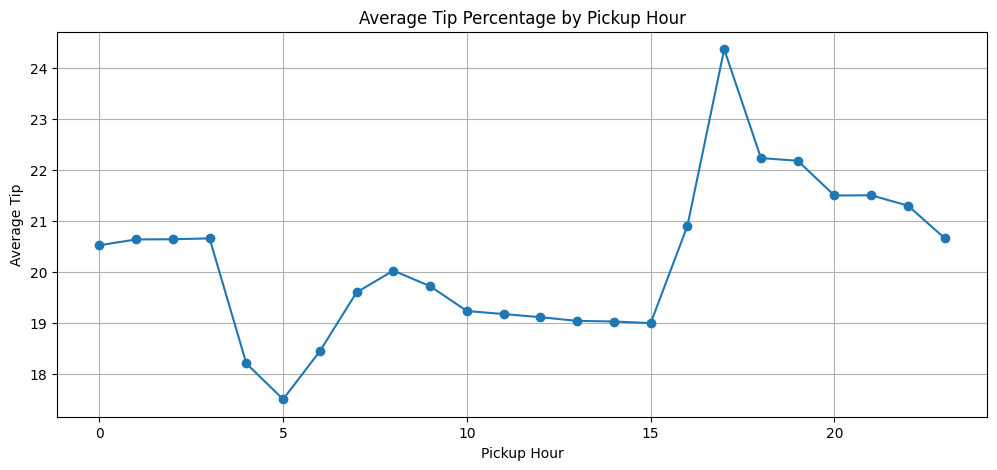

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

tip_df = df[(df["fare_amount"] > 0) & (df["trip_distance"] > 0)].copy()

tip_df["tip_percentage"] = (tip_df["tip_amount"] / tip_df["fare_amount"]) * 100

tip_df["distance_category"] = pd.cut(
    tip_df["trip_distance"],
    bins=[0, 2, 5, float("inf")],
    labels=["0-2 miles", "2-5 miles", "5> miles"],
)

print("Average Tip Percentage by Distance Category")
print(tip_df.groupby("distance_category")["tip_percentage"].mean())

print("\nAverage Tip Percentage by Passenger Count")
print(tip_df.groupby("passenger_count")["tip_percentage"].mean()
)

print("\nAverage Tip Percentage by Pickup Hour")
print(tip_df.groupby("pickup_hour")["tip_percentage"].mean())

plt.figure(figsize=(12,5))
tip_df.groupby("hour")["tip_percentage"].mean().plot(marker="o")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Tip")
plt.title("Average Tip Percentage by Pickup Hour")
plt.grid(True)
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip = tip_df[tip_df["tip_percentage"] < 10]
high_tip = tip_df[tip_df["tip_percentage"] > 25]

print("Low Tip Trips (<10%)")
print(low_tip[["trip_distance", "passenger_count", "fare_amount", "tip_percentage"]].describe())

print("\nHigh Tip Trips (>25%)")
print(high_tip[["trip_distance", "passenger_count", "fare_amount", "tip_percentage"]].describe())


Low Tip Trips (<10%)
       trip_distance  passenger_count    fare_amount  tip_percentage
count  493762.000000    493762.000000  493762.000000   493762.000000
mean        3.920051         1.429928      21.873629        1.083873
std         5.200432         0.911933     204.784539        2.655797
min         0.010000         1.000000       0.010000        0.000000
25%         1.080000         1.000000       9.300000        0.000000
50%         1.900000         1.000000      14.200000        0.000000
75%         4.020000         2.000000      24.700000        0.000000
max       204.860000         6.000000  143163.450000        9.991942

High Tip Trips (>25%)
       trip_distance  passenger_count    fare_amount  tip_percentage
count  852552.000000    852552.000000  852552.000000   852552.000000
mean        2.301257         1.363570      14.417366       32.521144
std         2.903562         0.861743      11.634495      379.359741
min         0.010000         1.000000       0.010000       

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

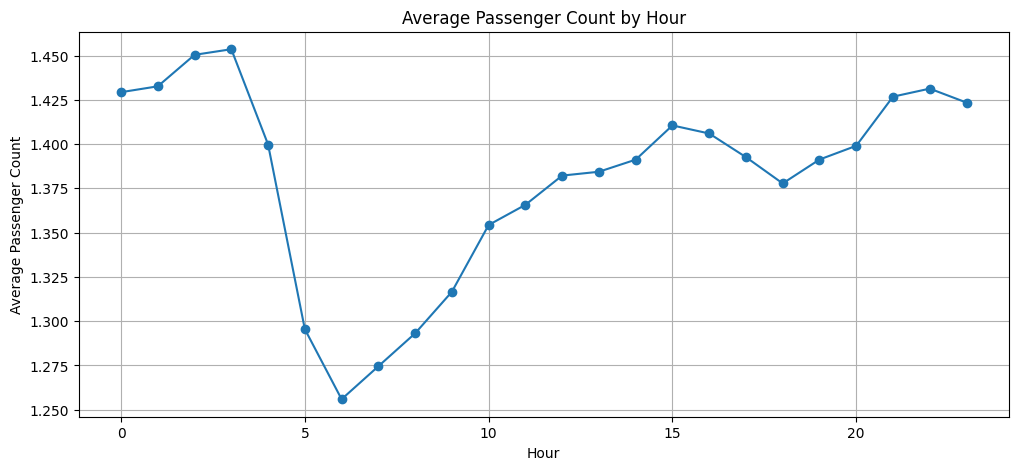

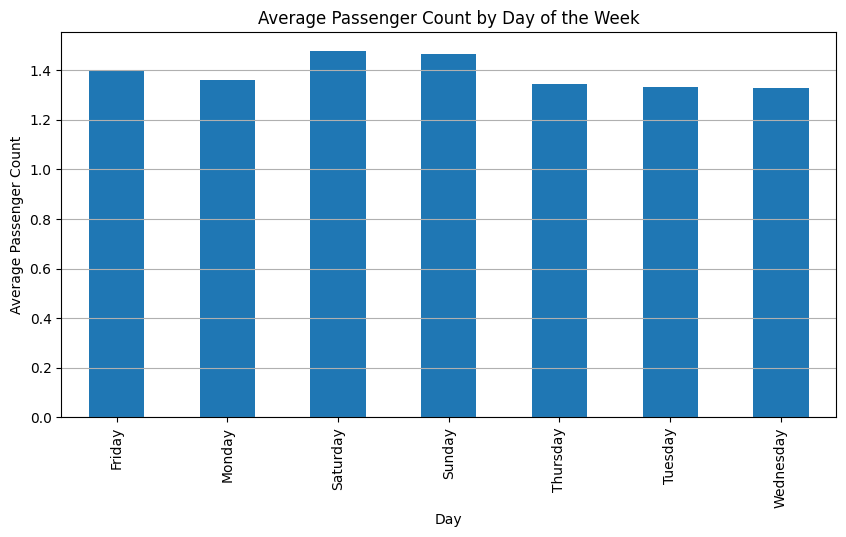

In [ ]:
# See how passenger count varies across hours and days

plt.figure(figsize=(12,5))

hourly_passenger = df.groupby("hour")["passenger_count"].mean()

plt.plot(hourly_passenger.index, hourly_passenger.values, marker="o")
plt.title("Average Passenger Count by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Passenger Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))

daily_passenger = df.groupby("pickup_day")["passenger_count"].mean()

daily_passenger.plot(kind="bar")
plt.title("Average Passenger Count by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Average Passenger Count")
plt.grid(axis="y")
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

     PULocationID  passenger_count
5               6         1.875000
196           204         1.800000
187           195         1.795238
11             12         1.734339
56             58         1.666667
170           178         1.666667
0               1         1.584071
64             66         1.572008
91             93         1.550617
252           261         1.542655


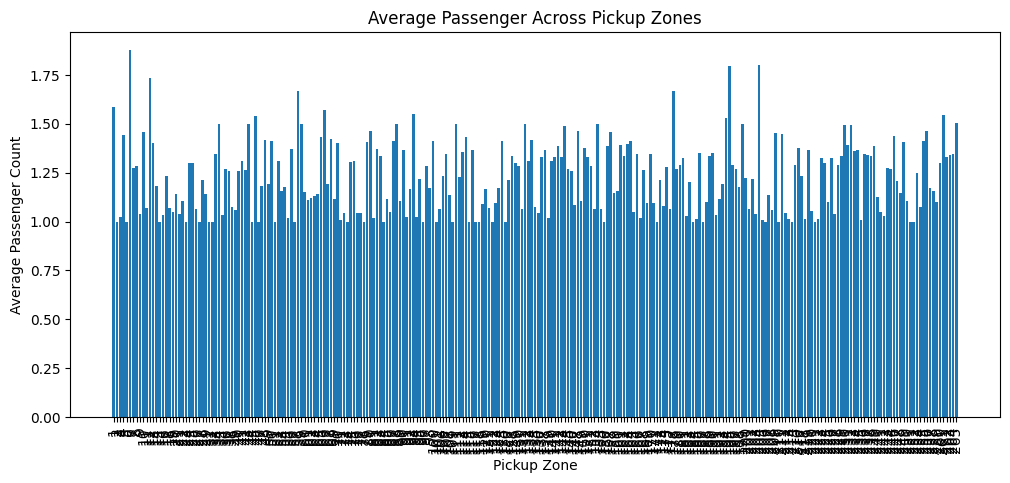

In [ ]:
# How does passenger count vary across zones

zone_passenger = df.groupby("PULocationID")["passenger_count"].mean().reset_index()

print(zone_passenger.sort_values(by="passenger_count", ascending=False).head(10))

plt.figure(figsize=(12,5))
plt.bar(zone_passenger["PULocationID"].astype(str), zone_passenger["passenger_count"])
plt.xticks(rotation=90)
plt.xlabel("Pickup Zone")
plt.ylabel("Average Passenger Count")
plt.title("Average Passenger Across Pickup Zones")
plt.show()

<Figure size 1000x1000 with 0 Axes>

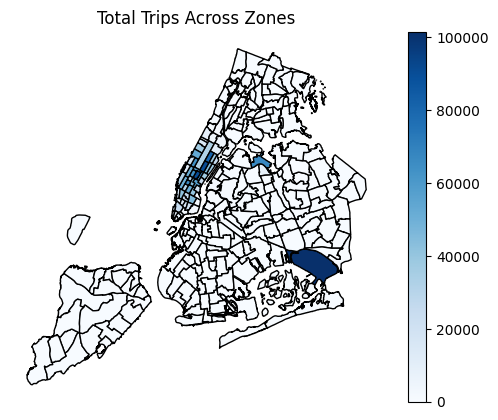

In [ ]:
# For a more detailed analysis, we can use the zones GeoDataFrame
# Create a new column for the average passenger count in each zone.


plt.figure(figsize=(10,10))

zones.plot(
    column="trip_count",
    cmap="Blues",
    legend=True,
    edgecolor="black"
)

plt.title("Total Trips Across Zones")
plt.axis("off")
plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently


extra
1189060

mta_tax
1901918

improvement_surcharge
1919038

congestion_surcharge
1772269


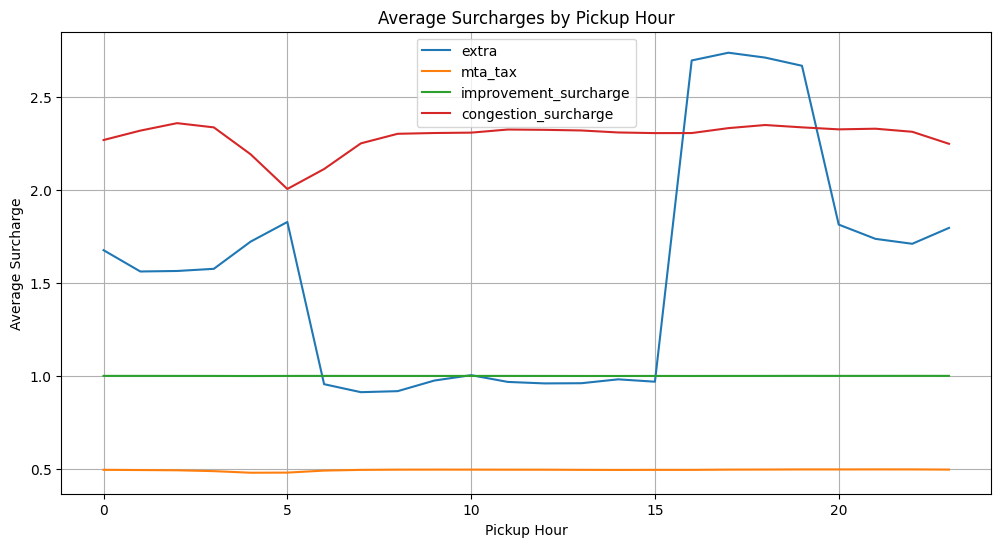

In [ ]:
# How often is each surcharge applied?

surcharge_cols = [
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "congestion_surcharge",
    "airport_fee"
]

# Check which surcharge columns are available
available_cols = [col for col in surcharge_cols if col in df.columns]

for col in available_cols:
    print(f"\n{col}")
    print(df[df[col] > 0][col].count())

# Pickup hour analysis
if "hour" in df.columns:
    surcharge_hour = df.groupby("hour")[available_cols].mean()

    plt.figure(figsize=(12,6))
    surcharge_hour.plot(ax=plt.gca())
    plt.title("Average Surcharges by Pickup Hour")
    plt.xlabel("Pickup Hour")
    plt.ylabel("Average Surcharge")
    plt.grid(True)
    plt.show()


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
# Recommendations for routing and dispatching

print("Recommendations for Routing and Dispatching")
print("- Increase taxi availability during morning and evening peak hours.")
print("- Deploy additional taxis on slow routes to reduce passenger waiting time.")
print("- Use historical traffic patterns to optimize driver dispatch.")
print("- Monitor high-demand pickup and dropoff zones in real time.")
print("- Reduce idle driving by assigning nearby drivers.")

Recommendations for Routing and Dispatching
- Increase taxi availability during morning and evening peak hours.
- Deploy additional taxis on slow routes to reduce passenger waiting time.
- Use historical traffic patterns to optimize driver dispatch.
- Monitor high-demand pickup and dropoff zones in real time.
- Reduce idle driving by assigning nearby drivers.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
# Recommendations for cab positioning

print("Recommendations for Cab Positioning")
print("- Position more taxis in the busiest pickup zones.")
print("- Keep additional taxis near airports, railway stations and commercial hubs.")
print("- Reallocate taxis based on hourly demand.")
print("- Position extra taxis in high-demand night zones.")
print("- Monitor zone-wise demand regularly to improve fleet utilisation.")

Recommendations for Cab Positioning
- Position more taxis in the busiest pickup zones.
- Keep additional taxis near airports, railway stations and commercial hubs.
- Reallocate taxis based on hourly demand.
- Position extra taxis in high-demand night zones.
- Monitor zone-wise demand regularly to improve fleet utilisation.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
# Recommendations for pricing strategy

print("Recommendations for Pricing Strategy")
print("- Apply dynamic pricing during peak demand hours.")
print("- Offer discounts during low-demand periods to increase trip volume.")
print("- Review vendor pricing differences regularly.")
print("- Optimise surcharge policies based on demand and traffic.")
print("- Encourage digital payments and tipping through incentives.")

Recommendations for Pricing Strategy
- Apply dynamic pricing during peak demand hours.
- Offer discounts during low-demand periods to increase trip volume.
- Review vendor pricing differences regularly.
- Optimise surcharge policies based on demand and traffic.
- Encourage digital payments and tipping through incentives.
